# Training the predictive model

This notebook trains and evaluates predictive models that forecast asset returns, volatility, and beta values following Donald Trump's social media events. Unlike the first version which trained separate models for each combination of asset, interval, and target variable, this notebook trains a multi-output model for each topic. Specifically, we train 6 Random Forest Regressors (one for each topic: China, Federal politics, Iran war/Oil, National security/Immigration, Tariffs, Technology) on 10 input features, predicting a 90-component target vector $y$.


## Environment Setup


In [145]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## Feature Engineering
We construct the input features. For the time-series features (lags and moving averages), we use the benchmark asset `ES` (E-mini S&P 500 futures) to capture the overall market conditions prior to the Trump post.  
Specifically, the 10 features are:
1. `word_count`
2. `hour_sin` (y-coordinate of a unit circle)
3. `hour_cos`(x-coordinate of a unit circle)
4. `return_1d_lag1` (1-day lagged ES return)
5. `vol_1d_lag1` (1-day lagged ES volatility)
6. `return_1d_sma5` (rolling 5-period SMA of ES 1-day returns)
7. `vol_1d_sma5` (rolling 5-period SMA of ES 1-day volatility)
8. `topic_*_sentiment` (product of sentiment score and one-hot encoded topic classification)


In [146]:
print("Loading data...")
evt_path = '../../data/event_study_results.csv'
df_evt = pd.read_csv(evt_path, encoding='utf-8', encoding_errors='replace')

# Drop duplicate event entries
df_evt = df_evt.drop_duplicates(subset=['timestamp_utc', 'message_snippet', 'asset'], keep='first')

# Load NLP dataset
nlp_path = '../../data/trump_posts_nlp.csv'
df_nlp = pd.read_csv(nlp_path, encoding='utf-8', encoding_errors='replace')

# Byte-level truncation to match message snippets generated by event_study_engine.cpp
def make_snippet_bytes(msg):
    msg_str = str(msg).replace('\n', '').replace('\r', '').replace('"', '')
    msg_bytes = msg_str.encode('utf-8', errors='replace')
    if len(msg_bytes) > 50:
        return (msg_bytes[:47] + b'...').decode('utf-8', errors='replace')
    return msg_bytes.decode('utf-8', errors='replace')

df_nlp['message_snippet'] = df_nlp['message'].apply(make_snippet_bytes)
df = df_nlp.drop_duplicates(subset=['timestamp_utc', 'message_snippet'], keep='first').copy()

# Replace invalid dummy Beta values like -99.0 with NaNs
for col in df.columns:
    if 'beta' in col:
        df.loc[df[col] <= -99.0, col] = np.nan
print("Finished loading data.")

Loading data...
Finished loading data.


We pivot the target columns so that for each event (post), we have 90 outputs: returns (6 assets * 5 intervals), volatility (6 assets * 5 intervals), and beta (6 assets * 5 intervals).  
We handle missing values (e.g. from market closures on weekends/holidays) by applying **Last Observation Carried Forward (LOCF)** chronologically. 


In [147]:
assets = ['X_BTCUSD', 'CL', 'ES', 'YM', 'ZN', 'I_NDX']
intervals = ['5m', '15m', '30m', '1h', '1d']
metrics = ['return', 'vol', 'beta']
target_base_cols = [f'{metric}_{interval}' for metric in metrics for interval in intervals]

print('Pivoting targets...')
df_pivot = df_evt.pivot(index=['timestamp_utc', 'message_snippet'], columns='asset', values=target_base_cols)
df_pivot.columns = [f'{col[0]}_{col[1]}' for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# Sort pivoted dataframe chronologically
df_pivot['timestamp_utc'] = pd.to_datetime(df_pivot['timestamp_utc'])
df_pivot = df_pivot.sort_values('timestamp_utc').reset_index(drop=True)

# Define target columns list
targets_ret = [f'return_{interval}_{asset}' for asset in assets for interval in intervals]
targets_vol = [f'vol_{interval}_{asset}' for asset in assets for interval in intervals]
targets_beta = [f'beta_{interval}_{asset}' for asset in assets for interval in intervals]
target_cols = targets_ret + targets_vol + targets_beta

# Apply Last Observation Carried Forward (LOCF) to replace NaNs
print('Applying LOCF...')
df_pivot[target_cols] = df_pivot[target_cols].ffill().bfill()

# Construct lagged and SMA features from ES data
df_pivot['return_1d_lag1'] = df_pivot['return_1d_ES'].shift(1)
df_pivot['vol_1d_lag1'] = df_pivot['vol_1d_ES'].shift(1)

df_pivot['return_1d_sma5'] = df_pivot['return_1d_ES'].rolling(5, min_periods=1).mean()
df_pivot['vol_1d_sma5'] = df_pivot['vol_1d_ES'].rolling(5, min_periods=1).mean()

# Fill NaNs in lagged and SMA features
feature_cols = ['return_1d_lag1', 'vol_1d_lag1', 'return_1d_sma5', 'vol_1d_sma5']
for col in feature_cols:
    df_pivot[col] = df_pivot[col].ffill().bfill()
    df_pivot[col] = df_pivot[col].fillna(0.0)

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
df_posts = df[df['topic'] != 'Miscellaneous'].copy() # filter out Miscellaneous posts

# Add post features
df_posts['word_count'] = df_posts['message'].astype(str).str.split().str.len()
df_posts['hour'] = df_posts['timestamp_utc'].dt.hour
df_posts['hour_sin'] = np.sin(2 * np.pi * df_posts['hour'] / 24.0)
df_posts['hour_cos'] = np.cos(2 * np.pi * df_posts['hour'] / 24.0)

# Topic-sentiment interaction
topic_dummies = pd.get_dummies(df_posts['topic'], prefix='topic', dtype=float)
topic_sentiment_features = topic_dummies.multiply(df_posts['sentiment_score'], axis=0)
topic_sentiment_features.columns = [f'{col}_sentiment' for col in topic_sentiment_features.columns]
df_posts = pd.concat([df_posts, topic_sentiment_features], axis=1)

# Merge pivoted dataframe with post-related features
df_final = pd.merge(df_posts, df_pivot, on=['timestamp_utc', 'message_snippet'], how='inner')

# Save final dataset
data_dir = '../../data'
os.makedirs(data_dir, exist_ok=True)
df_final.to_csv(f'{data_dir}/final_dataset.csv', index=False)

print(f'Final dataset has {len(df_final)} rows and {len(target_cols)} targets. Saved to data/ folder.')


Pivoting targets...
Applying LOCF...
Final dataset has 3077 rows and 90 targets. Saved to data/ folder.


## Model Setup and Training
We split the data chronologically (80% training, 20% testing) for each topic to prevent look-ahead bias. We then train a baseline multi-output Linear Regression and a multi-output Random Forest Regressor for each of the 6 topics.


In [148]:
# RandomForestRegressor configuration
rf_params = {
    'n_estimators': 100,
    'random_state': 42,
    'n_jobs': -1
}

topics = ['China', 'Federal politics', 'Iran war/Oil', 'National security/Immigration', 'Tariffs', 'Technology']

results_regression = []
results_importances = []

print('Starting model training across all topics...')
for topic in topics:
    df_topic = df_final[df_final['topic'] == topic].copy()
    if len(df_topic) < 20:
        print(f'Skipping topic {topic} due to insufficient data ({len(df_topic)} rows).')
        continue
        
    print(f'Training models for topic {topic} ({len(df_topic)} rows)...')
    
    # Sort chronologically
    df_topic = df_topic.sort_values('timestamp_utc')
    
    # Input features (10 dimensions)
    topic_sent_col = f'topic_{topic}_sentiment'
    input_cols = [ 
        'word_count', 'hour_sin', 'hour_cos',
        'return_1d_lag1', 'vol_1d_lag1',
        'return_1d_sma5', 'vol_1d_sma5',
        topic_sent_col
    ]
    
    X = df_topic[input_cols].values
    y = df_topic[target_cols].values
    
    # Chronological Split
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Predictive Model: Random Forest wrapped in MultiOutputRegressor to extract component-level importances
    from sklearn.multioutput import MultiOutputRegressor
    rf_base = RandomForestRegressor(n_estimators=rf_params['n_estimators'], random_state=rf_params['random_state'], n_jobs=1)
    rf = MultiOutputRegressor(rf_base, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_preds = rf.predict(X_test)
    
    # Store performance metrics for each component
    for idx, col in enumerate(target_cols):
        parts = col.split('_')
        metric = parts[0].capitalize()  # Return, Vol, Beta
        interval = parts[1]
        asset = '_'.join(parts[2:])
        
        y_t = y_test[:, idx]
        rf_p = rf_preds[:, idx]
        
        rf_r2 = r2_score(y_t, rf_p)
        rf_rmse = np.sqrt(mean_squared_error(y_t, rf_p))
        
        results_regression.append({
            'Topic': topic, 'Asset': asset, 'Interval': interval, 'Target param': metric,
            'RF_R2': rf_r2, 'RF_RMSE': rf_rmse,
            'Target_Std': np.std(y_t)
        })
        
        # Store feature importances for each target component
        est = rf.estimators_[idx]
        results_importances.append({
            'Topic': topic,
            'Asset': asset,
            'Interval': interval,
            'Target param': metric,
            'word_count': est.feature_importances_[0],
            'hour_sin': est.feature_importances_[1],
            'hour_cos': est.feature_importances_[2],
            'return_1d_lag1': est.feature_importances_[3],
            'vol_1d_lag1': est.feature_importances_[4],
            'return_1d_sma5': est.feature_importances_[5],
            'vol_1d_sma5': est.feature_importances_[6],
            'topic_sentiment': est.feature_importances_[7]
        })

df_reg = pd.DataFrame(results_regression)
df_importances = pd.DataFrame(results_importances)


Starting model training across all topics...
Training models for topic China (68 rows)...
Training models for topic Federal politics (2061 rows)...
Training models for topic Iran war/Oil (184 rows)...
Training models for topic National security/Immigration (469 rows)...
Training models for topic Tariffs (231 rows)...
Training models for topic Technology (64 rows)...


## Saving Performance Metrics and Importances
We save the metrics to the `results/` directory.


In [ ]:
results_dir = 'results' if os.path.exists('results') else '../../results'

# Summary of model performance
print('=== Summary of R2, RMSE and Target Std Dev scores ===')
print(df_reg.groupby(['Target param'])[['RF_R2', 'RF_RMSE', 'Target_Std']].mean())

# Save to CSVs
os.makedirs(results_dir, exist_ok=True)
df_reg.to_csv(f'{results_dir}/model_performance_metrics.csv', index=False)
df_importances.to_csv(f'{results_dir}/model_feature_importances.csv', index=False)
print('Performance metrics and feature importances have been written to results/ folder!')

=== Summary of R2, RMSE and Target Std Dev scores ===
                   RF_R2   RF_RMSE  Target_Std
Target param                                  
Beta           -1.112577  0.898797    0.715030
Return         -0.193795  0.004512    0.004483
Vol          -378.569770  0.000073    0.000062
Performance metrics and feature importances have been written to results/ folder!


## Diagnostics
We plot the $R^2$ scores of each topic's Random Forest models across different assets and intervals for predicting returns, volatility, and beta. The red horizontal line marks $R^2=0$. A topic-asset pair is considered to exhibit strong correlation at a suitable time interval when $R^2>0.5$. After finding the strongly correlated topic-asset pairs, we further support the observed good accuracy of the predicted financial data by examining the root mean squared error (RMSE).

### X_BTCUSD

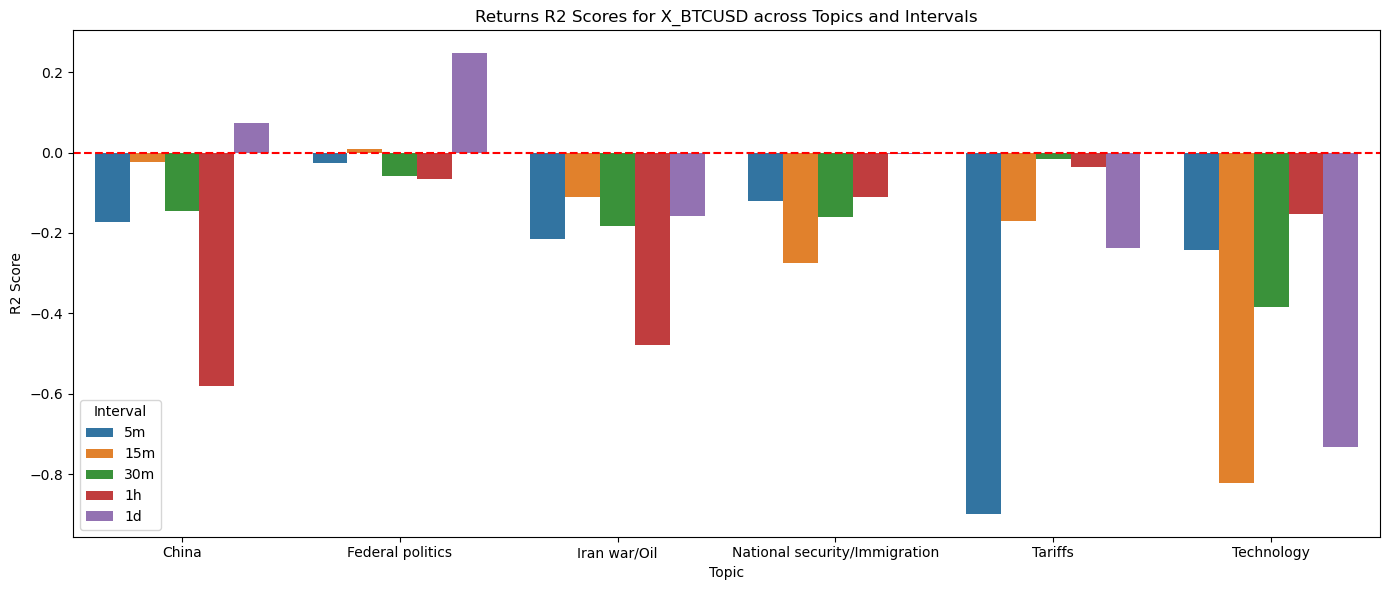

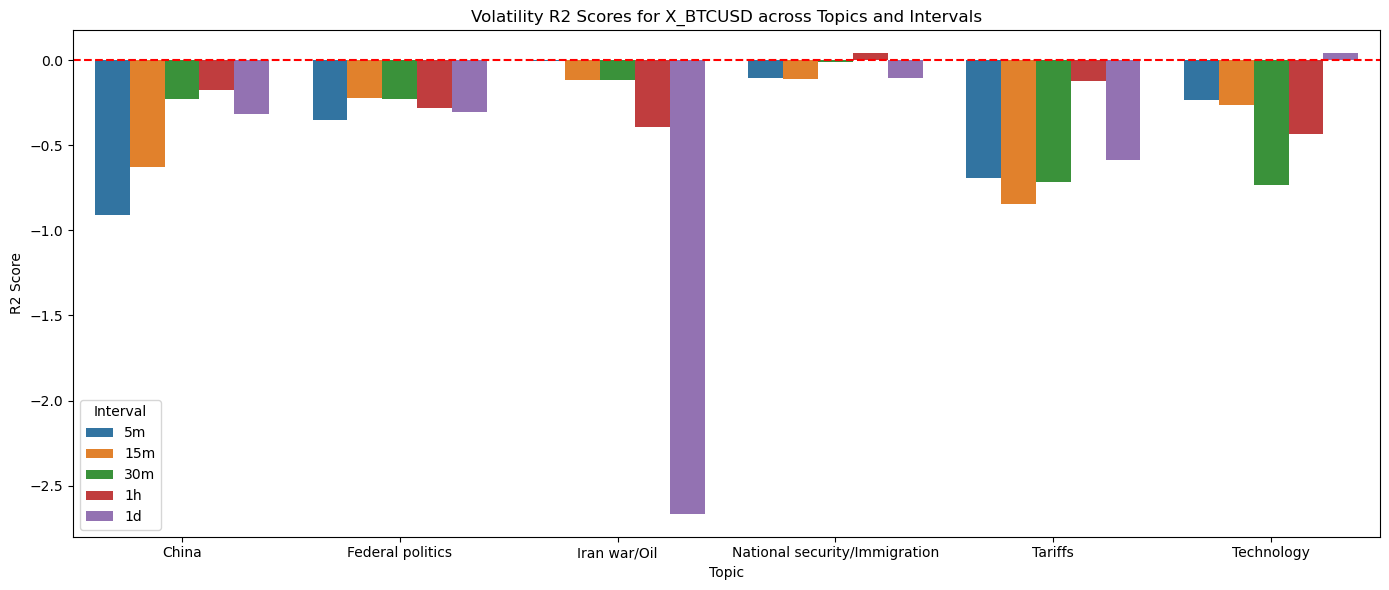

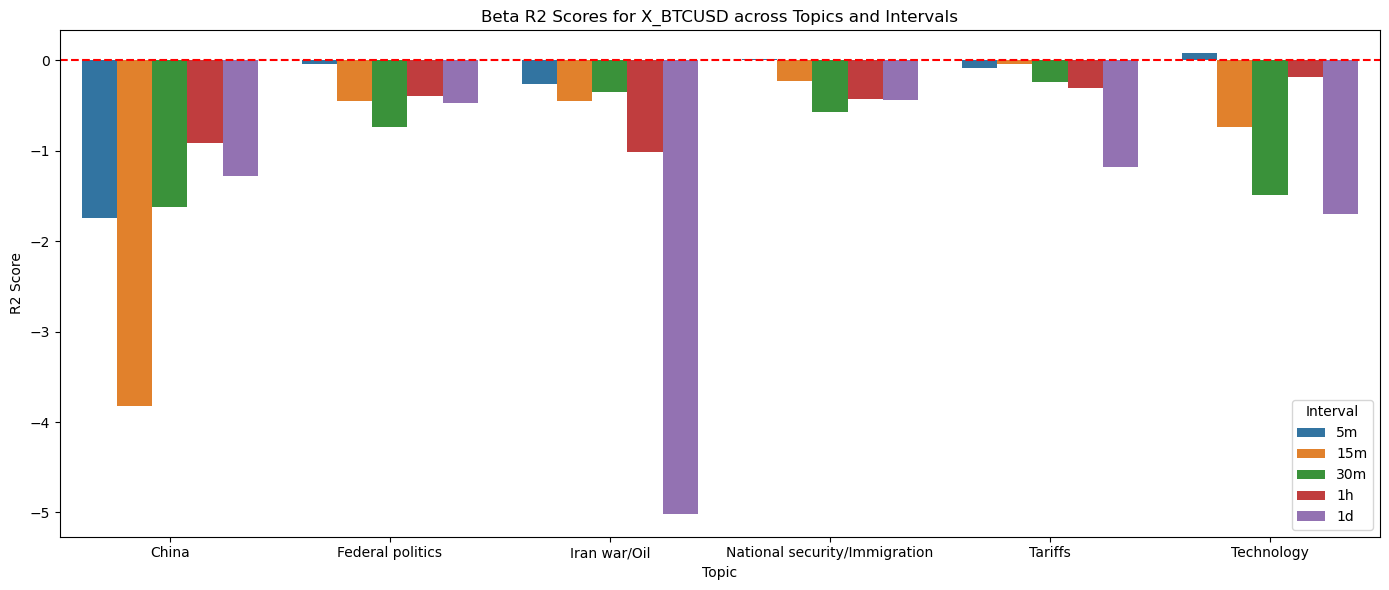

In [6]:
# Visualizing Returns for X_BTCUSD
df_ret = df_reg[(df_reg['Target param'] == 'Return') & (df_reg['Asset'] == 'X_BTCUSD')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ret, x='Topic', y='RF_R2', hue='Interval')
plt.title('Returns R2 Scores for X_BTCUSD across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Volatility for X_BTCUSD
df_vol = df_reg[(df_reg['Target param'] == 'Vol') & (df_reg['Asset'] == 'X_BTCUSD')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_vol, x='Topic', y='RF_R2', hue='Interval')
plt.title('Volatility R2 Scores for X_BTCUSD across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Beta for X_BTCUSD
df_beta = df_reg[(df_reg['Target param'] == 'Beta') & (df_reg['Asset'] == 'X_BTCUSD')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_beta, x='Topic', y='RF_R2', hue='Interval')
plt.title('Beta R2 Scores for X_BTCUSD across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


### CL

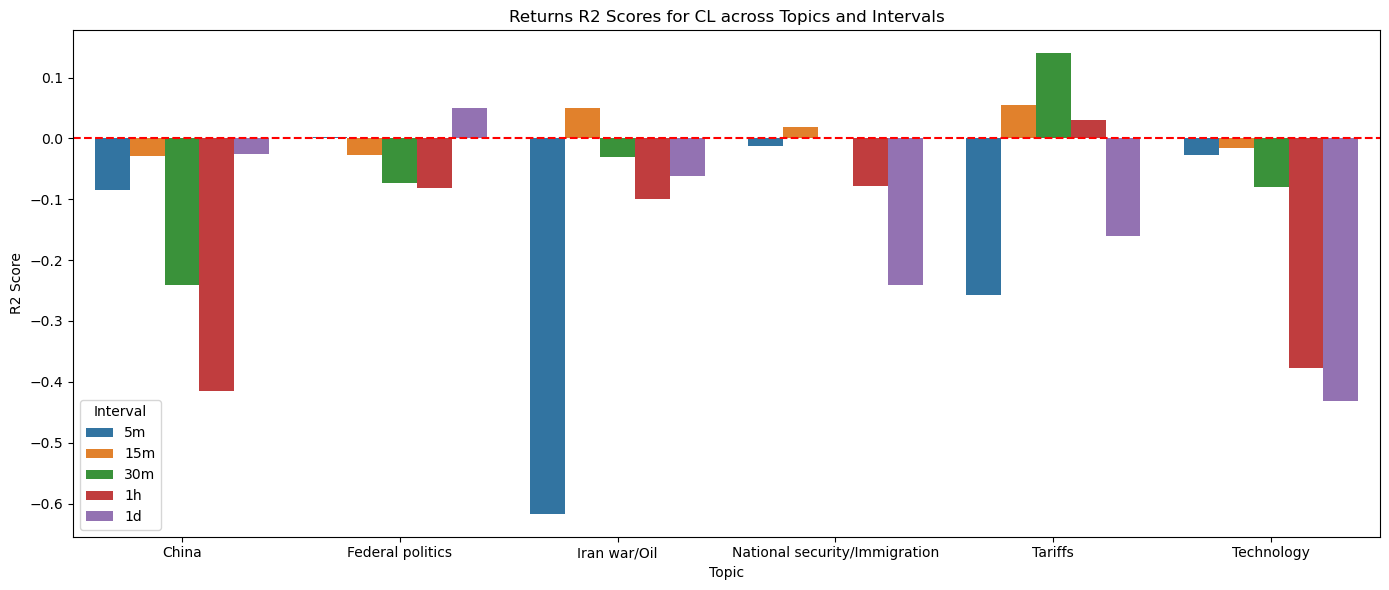

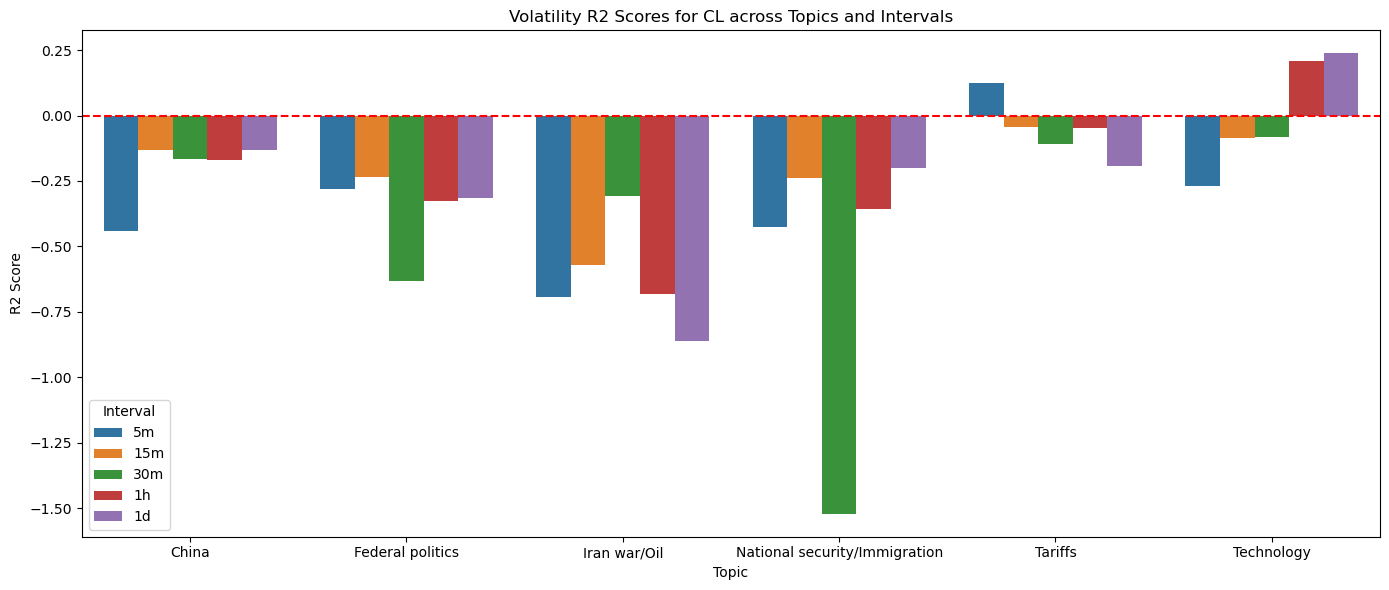

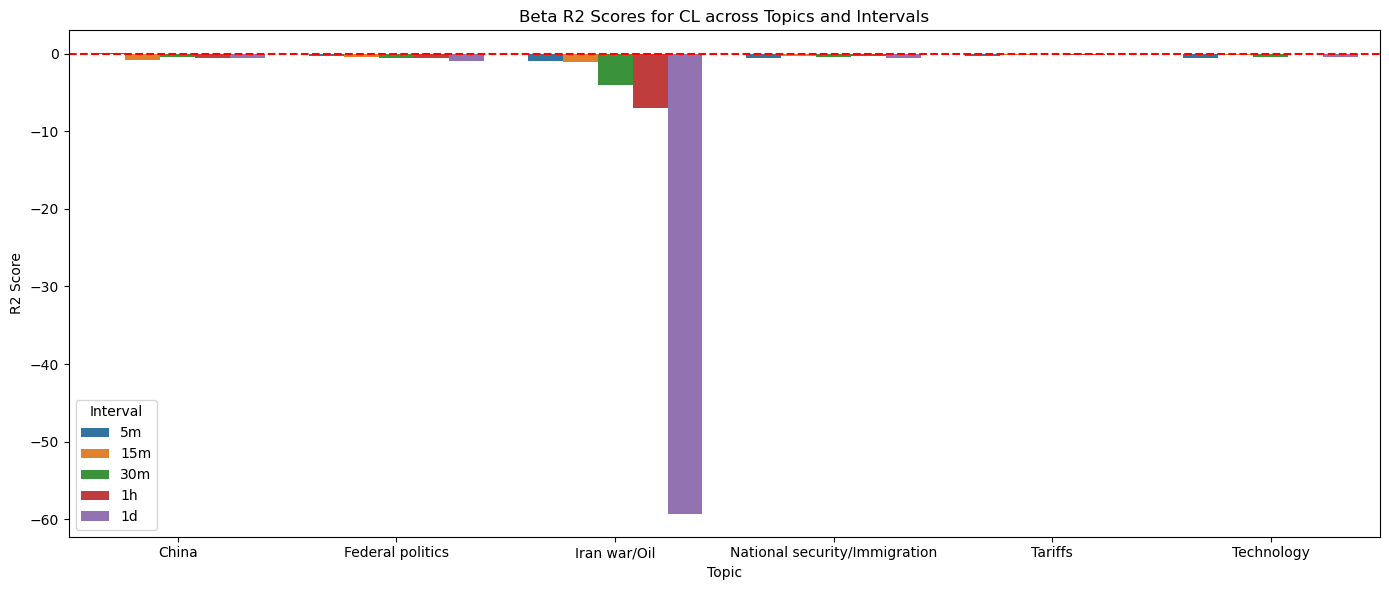

In [7]:
# Visualizing Returns for CL
df_ret = df_reg[(df_reg['Target param'] == 'Return') & (df_reg['Asset'] == 'CL')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ret, x='Topic', y='RF_R2', hue='Interval')
plt.title('Returns R2 Scores for CL across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Volatility for CL
df_vol = df_reg[(df_reg['Target param'] == 'Vol') & (df_reg['Asset'] == 'CL')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_vol, x='Topic', y='RF_R2', hue='Interval')
plt.title('Volatility R2 Scores for CL across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Beta for CL
df_beta = df_reg[(df_reg['Target param'] == 'Beta') & (df_reg['Asset'] == 'CL')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_beta, x='Topic', y='RF_R2', hue='Interval')
plt.title('Beta R2 Scores for CL across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### ZN

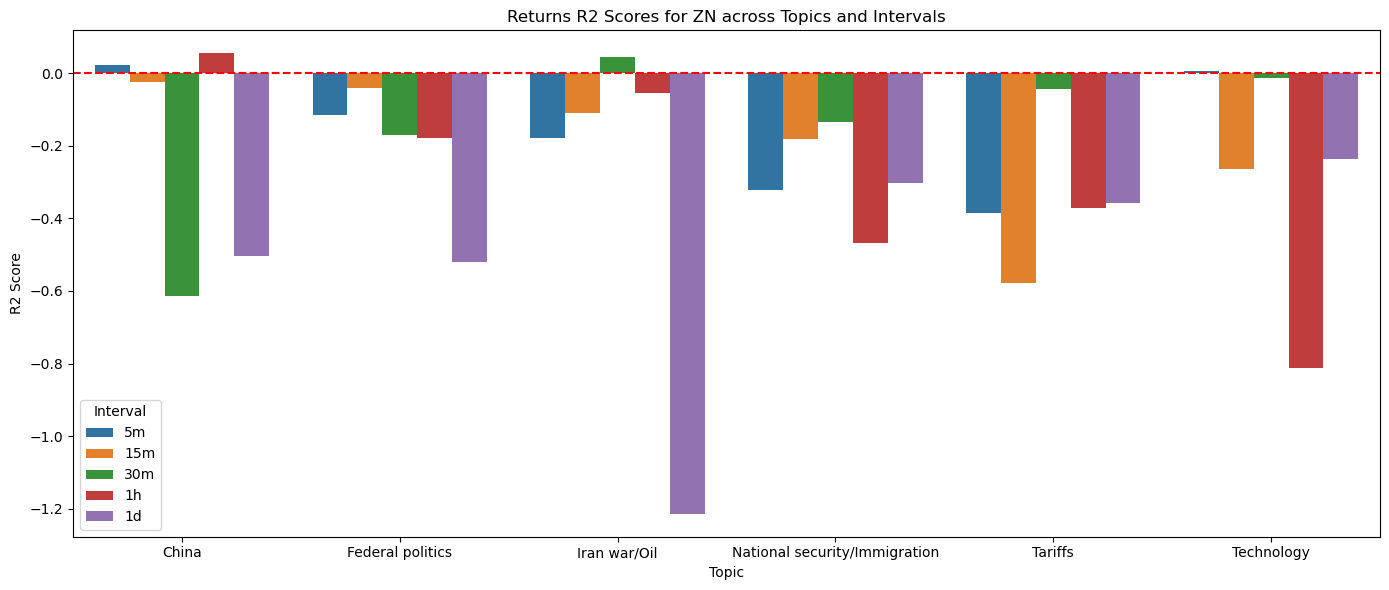

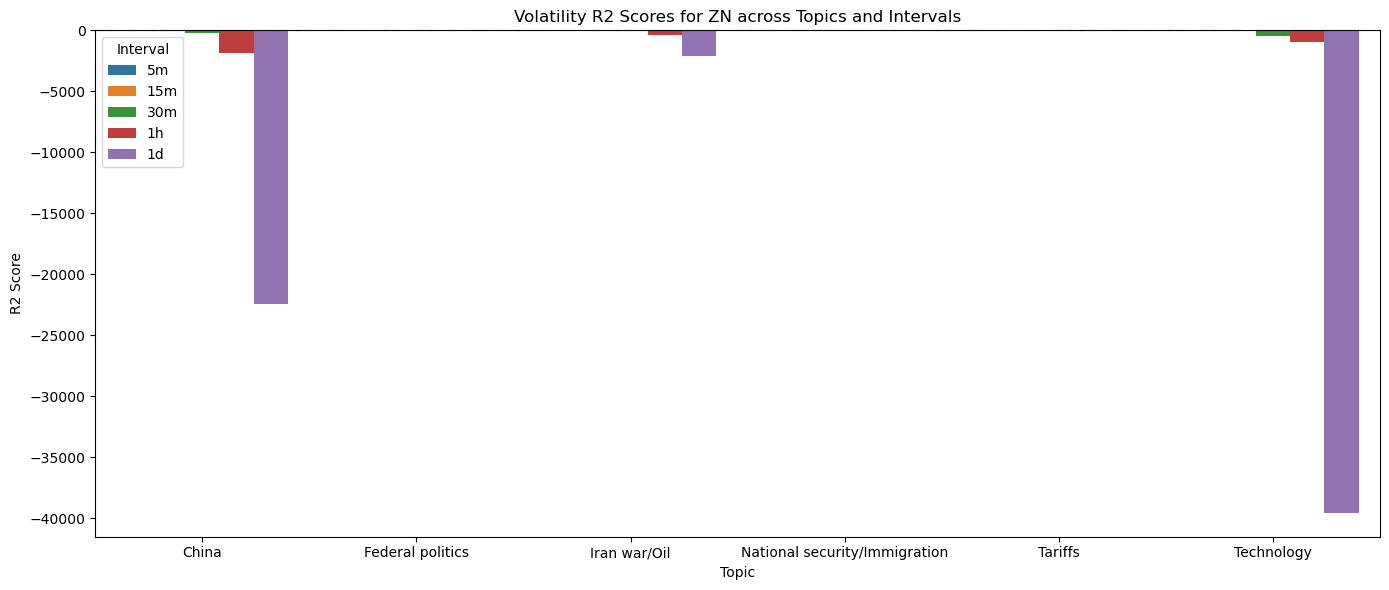

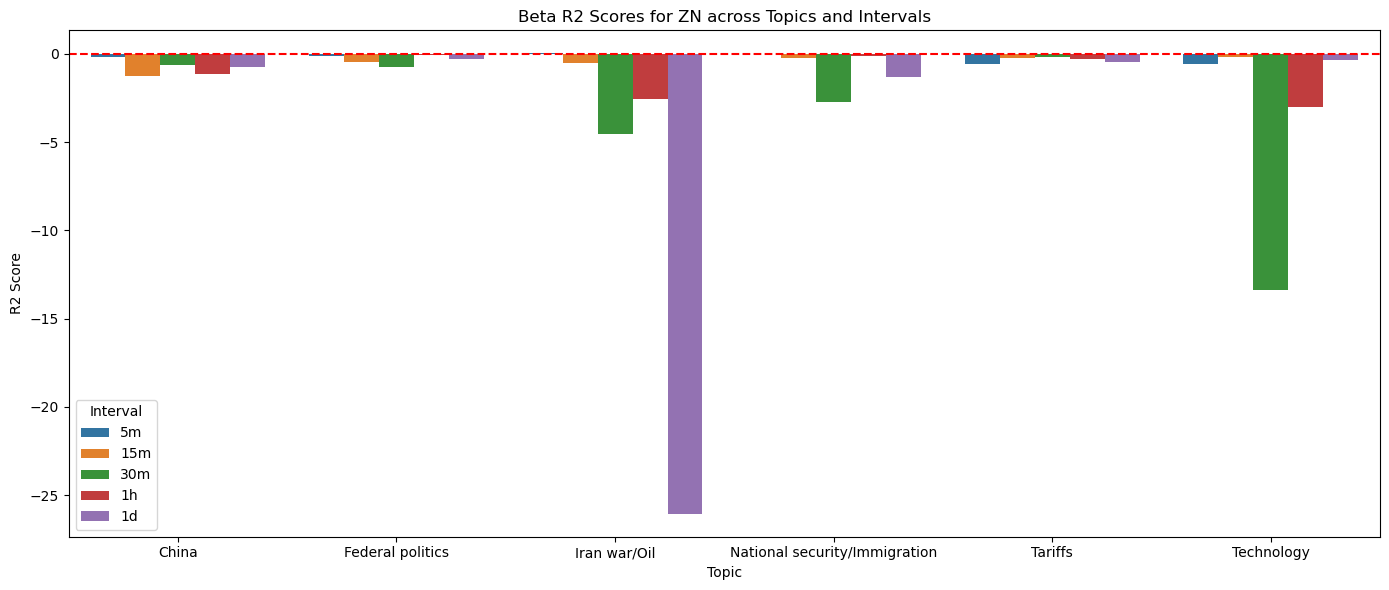

In [8]:
# Visualizing Returns for ZN
df_ret = df_reg[(df_reg['Target param'] == 'Return') & (df_reg['Asset'] == 'ZN')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ret, x='Topic', y='RF_R2', hue='Interval')
plt.title('Returns R2 Scores for ZN across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Volatility for ZN
df_vol = df_reg[(df_reg['Target param'] == 'Vol') & (df_reg['Asset'] == 'ZN')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_vol, x='Topic', y='RF_R2', hue='Interval')
plt.title('Volatility R2 Scores for ZN across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Beta for ZN
df_beta = df_reg[(df_reg['Target param'] == 'Beta') & (df_reg['Asset'] == 'ZN')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_beta, x='Topic', y='RF_R2', hue='Interval')
plt.title('Beta R2 Scores for ZN across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### ES

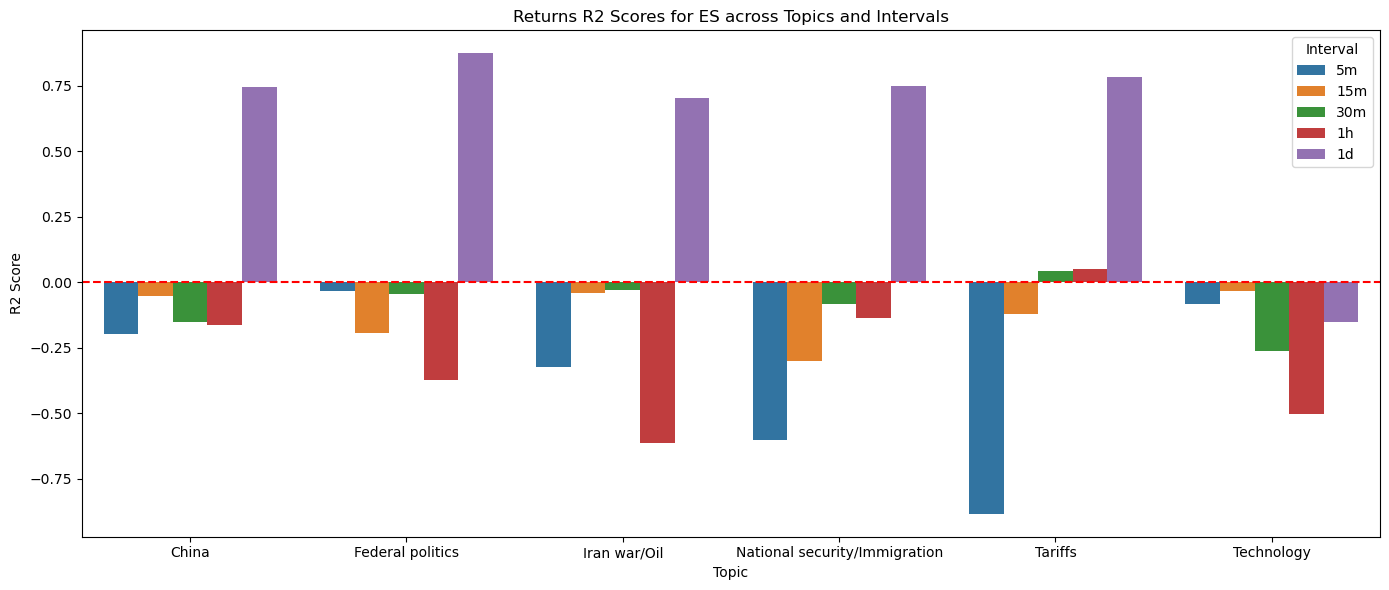

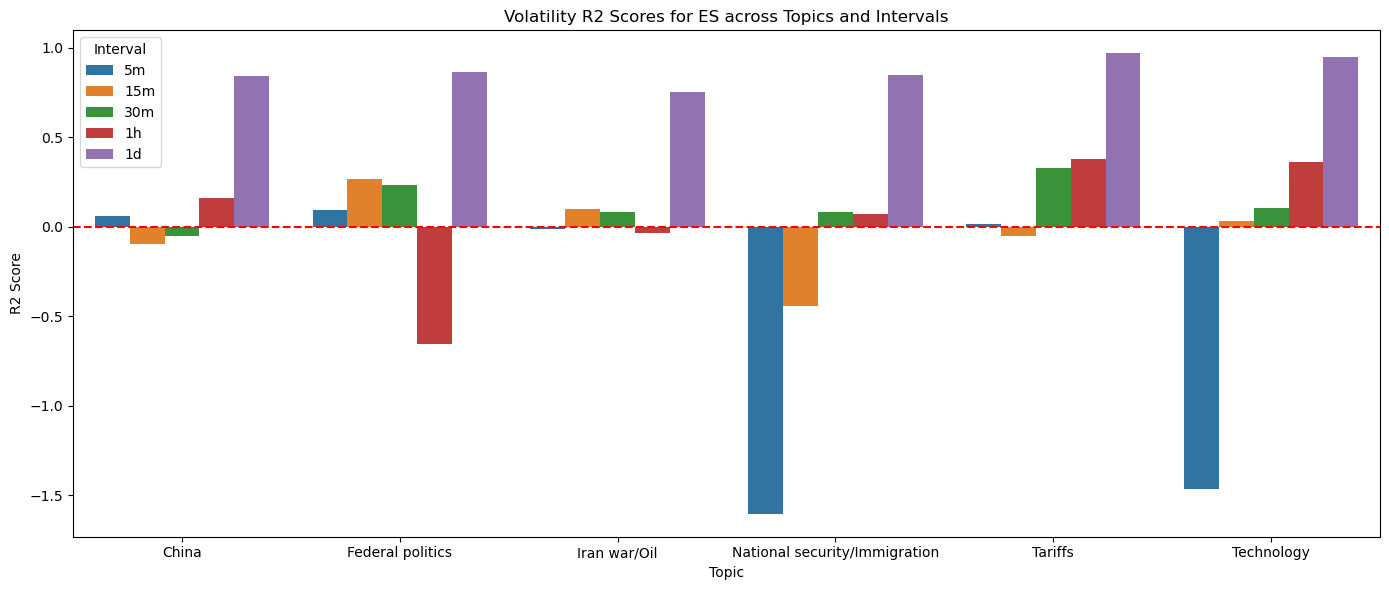

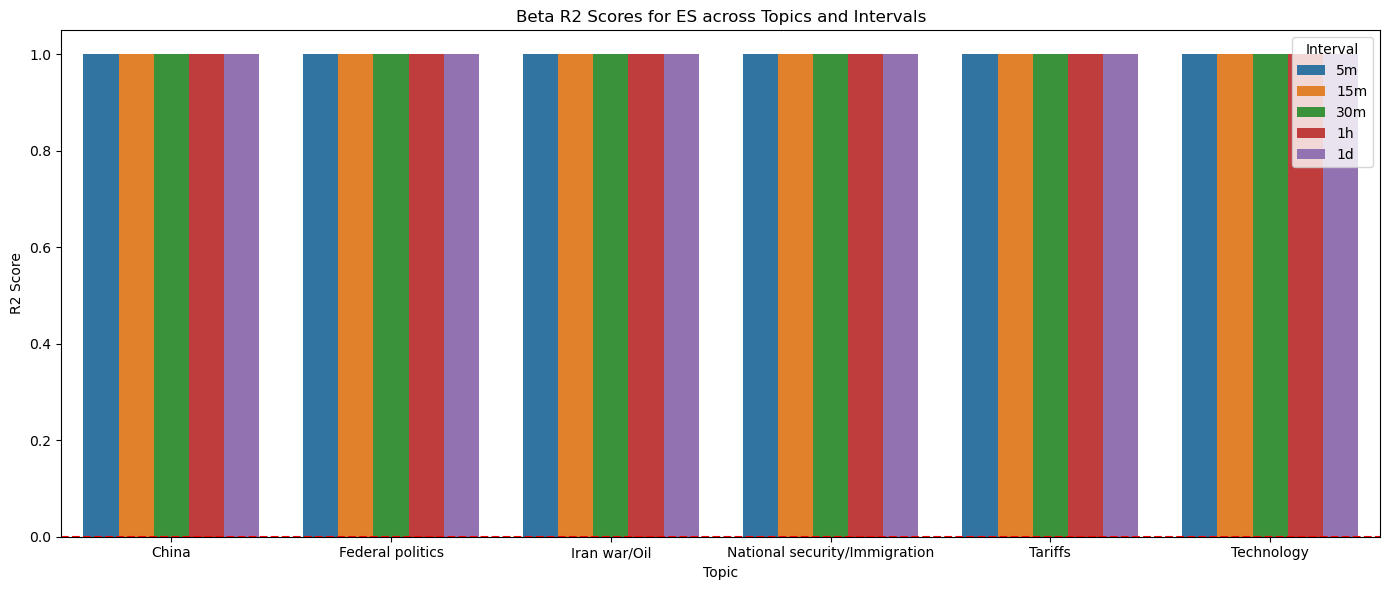

In [9]:
# Visualizing Returns for ES
df_ret = df_reg[(df_reg['Target param'] == 'Return') & (df_reg['Asset'] == 'ES')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ret, x='Topic', y='RF_R2', hue='Interval')
plt.title('Returns R2 Scores for ES across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Volatility for ES
df_vol = df_reg[(df_reg['Target param'] == 'Vol') & (df_reg['Asset'] == 'ES')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_vol, x='Topic', y='RF_R2', hue='Interval')
plt.title('Volatility R2 Scores for ES across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Beta for ES
df_beta = df_reg[(df_reg['Target param'] == 'Beta') & (df_reg['Asset'] == 'ES')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_beta, x='Topic', y='RF_R2', hue='Interval')
plt.title('Beta R2 Scores for ES across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### YM

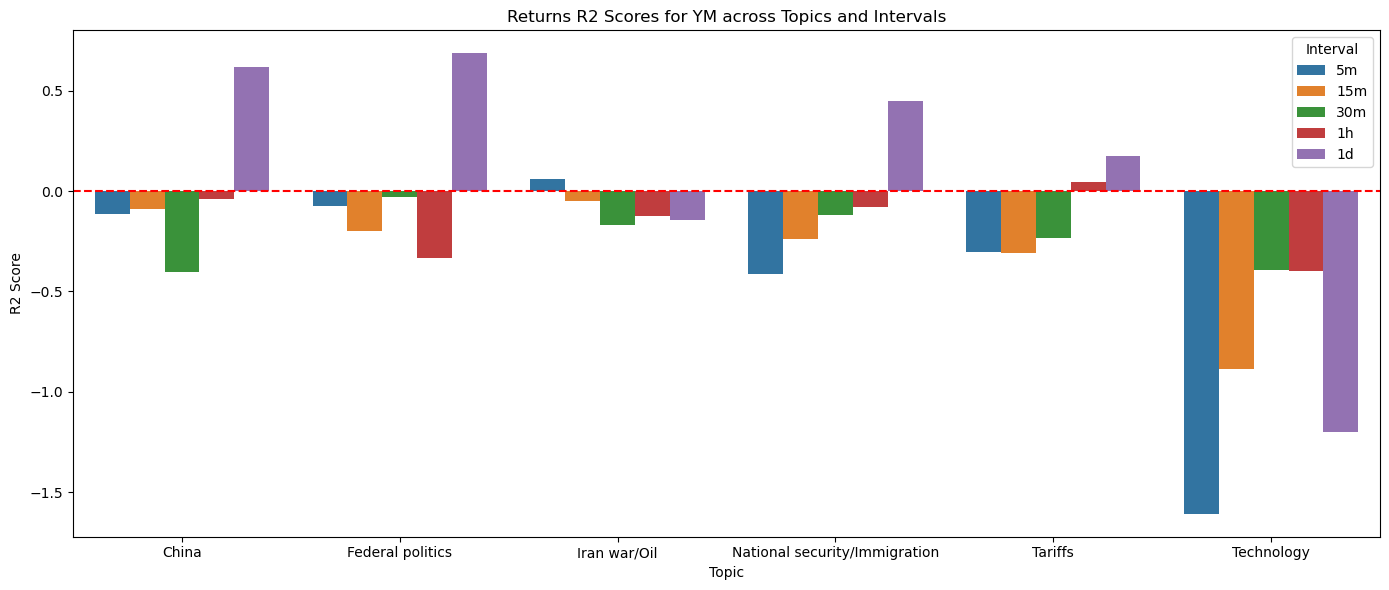

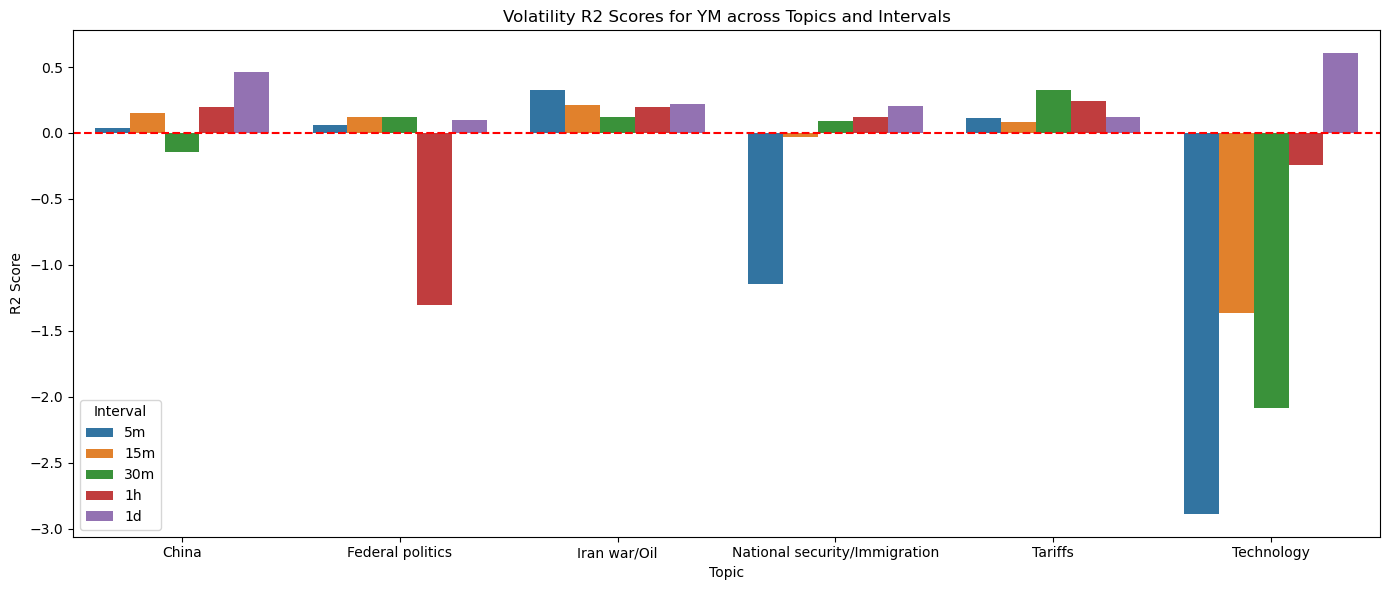

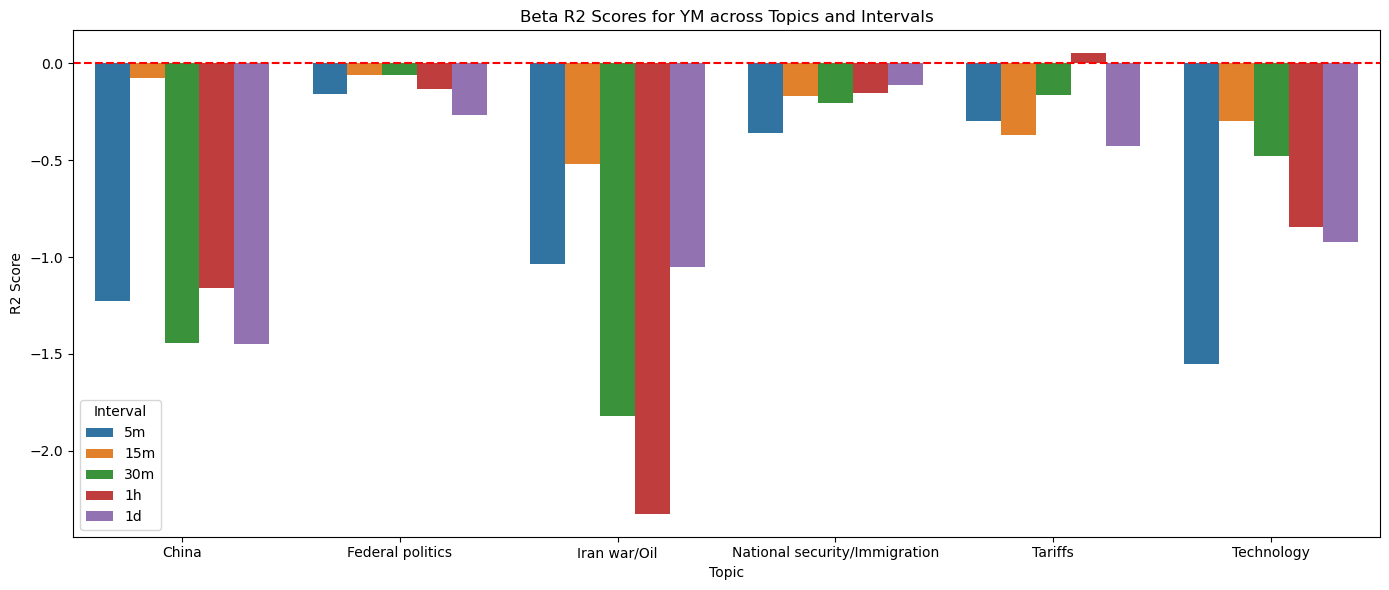

In [10]:
# Visualizing Returns for YM
df_ret = df_reg[(df_reg['Target param'] == 'Return') & (df_reg['Asset'] == 'YM')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ret, x='Topic', y='RF_R2', hue='Interval')
plt.title('Returns R2 Scores for YM across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Volatility for YM
df_vol = df_reg[(df_reg['Target param'] == 'Vol') & (df_reg['Asset'] == 'YM')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_vol, x='Topic', y='RF_R2', hue='Interval')
plt.title('Volatility R2 Scores for YM across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Beta for YM
df_beta = df_reg[(df_reg['Target param'] == 'Beta') & (df_reg['Asset'] == 'YM')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_beta, x='Topic', y='RF_R2', hue='Interval')
plt.title('Beta R2 Scores for YM across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### I_NDX

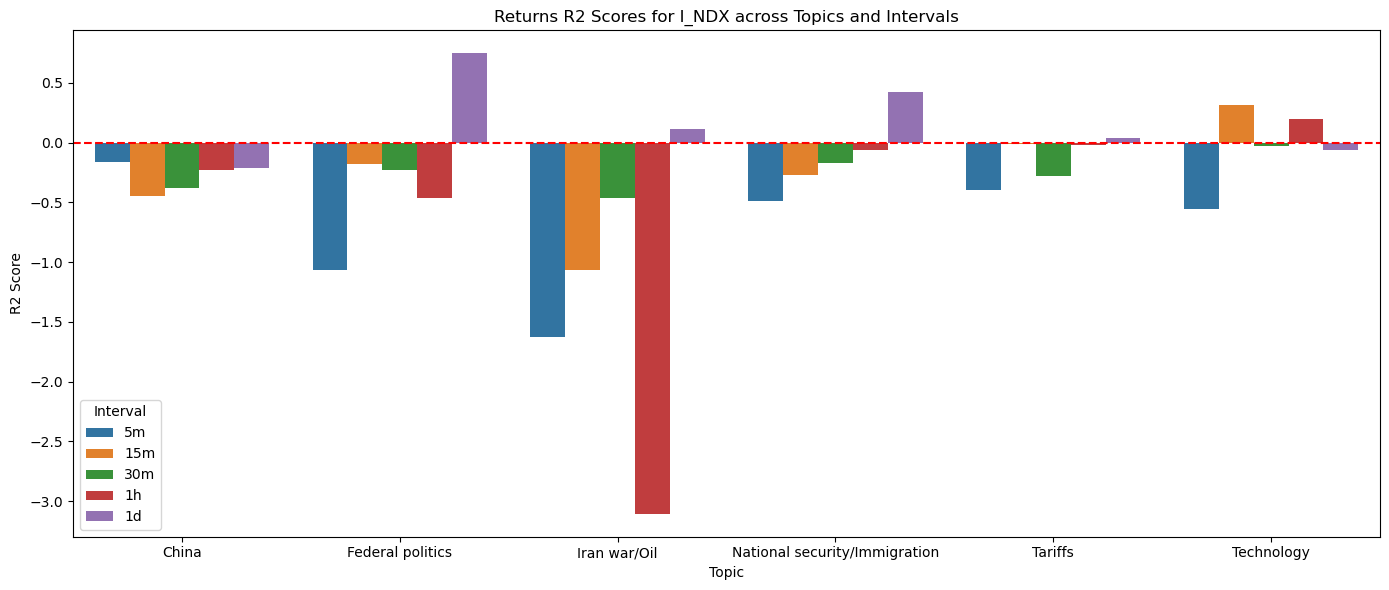

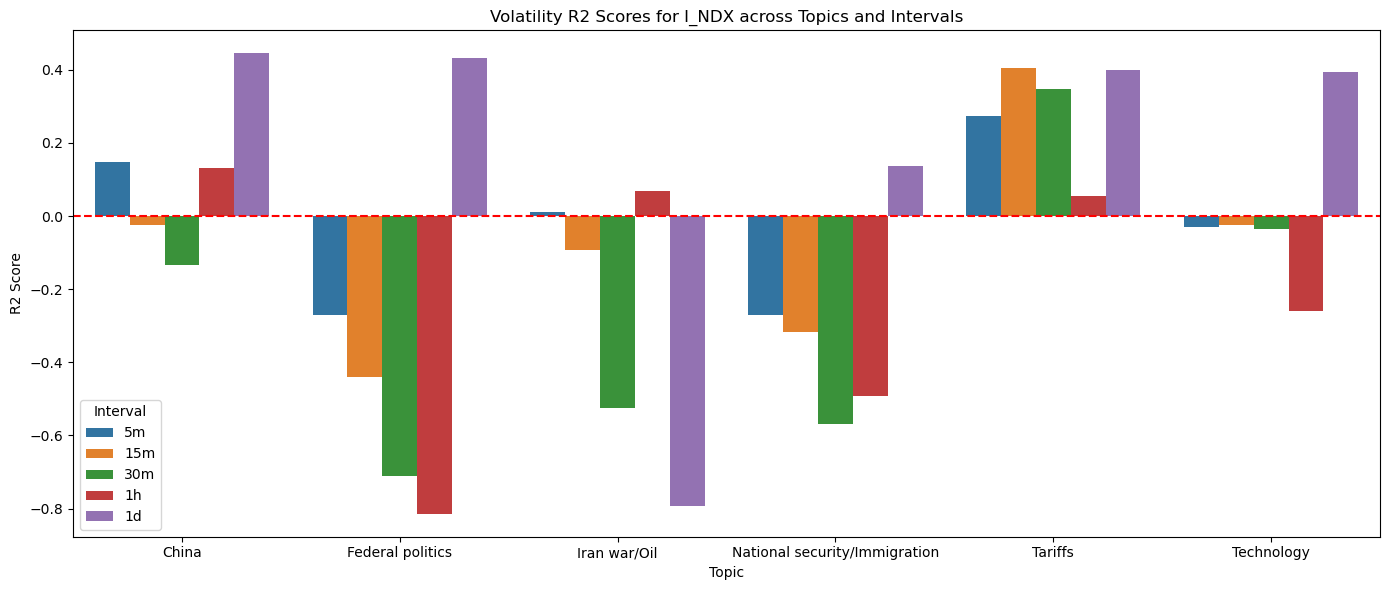

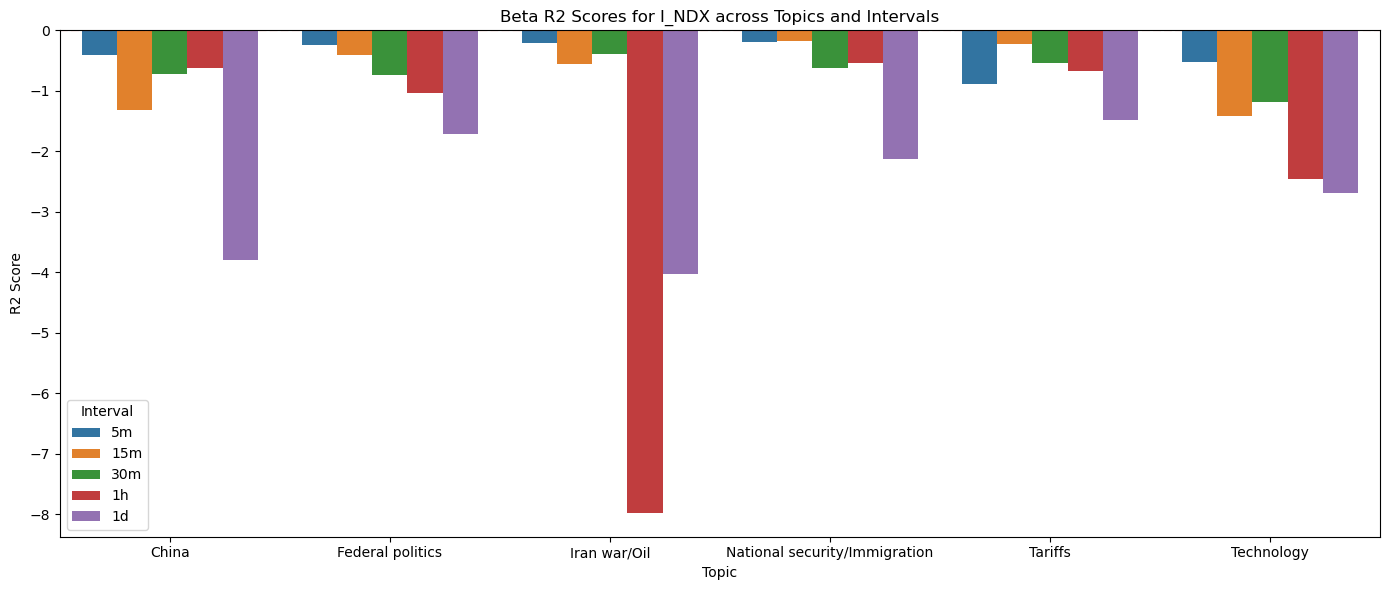

In [11]:
# Visualizing Returns for I_NDX
df_ret = df_reg[(df_reg['Target param'] == 'Return') & (df_reg['Asset'] == 'I_NDX')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ret, x='Topic', y='RF_R2', hue='Interval')
plt.title('Returns R2 Scores for I_NDX across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Volatility for I_NDX
df_vol = df_reg[(df_reg['Target param'] == 'Vol') & (df_reg['Asset'] == 'I_NDX')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_vol, x='Topic', y='RF_R2', hue='Interval')
plt.title('Volatility R2 Scores for I_NDX across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing Beta for I_NDX
df_beta = df_reg[(df_reg['Target param'] == 'Beta') & (df_reg['Asset'] == 'I_NDX')]
plt.figure(figsize=(14, 6))
sns.barplot(data=df_beta, x='Topic', y='RF_R2', hue='Interval')
plt.title('Beta R2 Scores for I_NDX across Topics and Intervals')
plt.ylabel('R2 Score')
plt.xlabel('Topic')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


### RMSE
"Good" $R^2$ scores (ie. $>0.5$) were found for the following assets, topics, and target variables:
- CL Technology 1-hr & 1-day volatility
- ES all topics except Technology 1-day returns & volatility
- YM China 1-hr & 1-day returns
- YM Federal politics 1-day returns
- I_NDX Federal politics 1-day returns

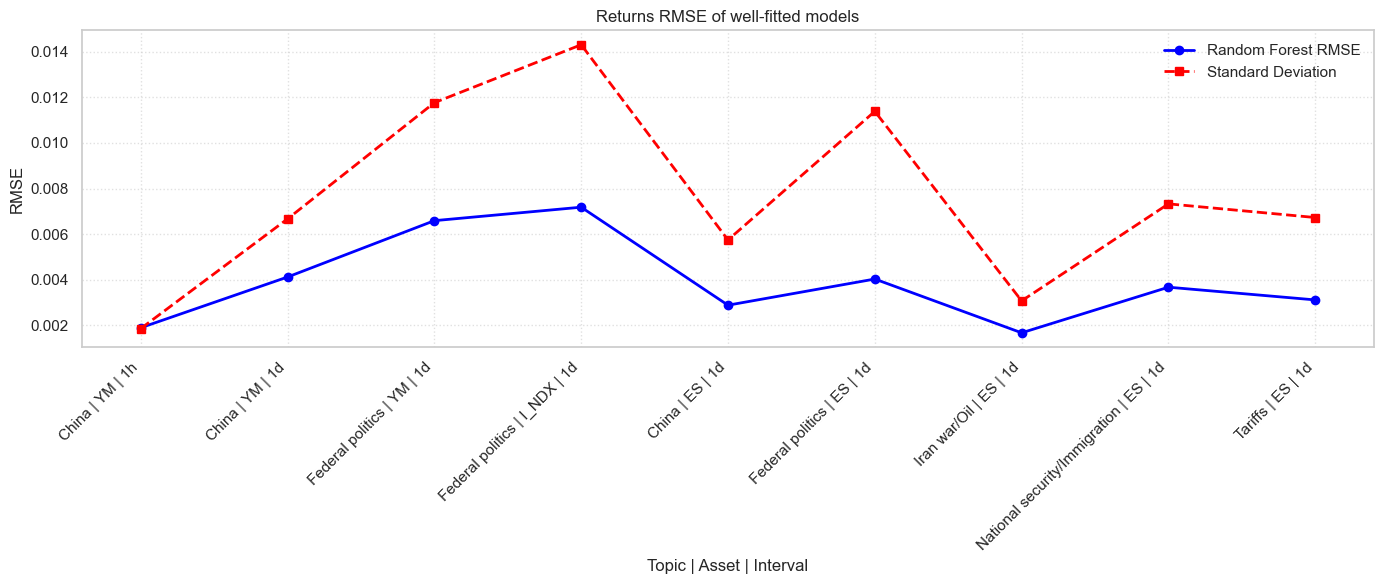

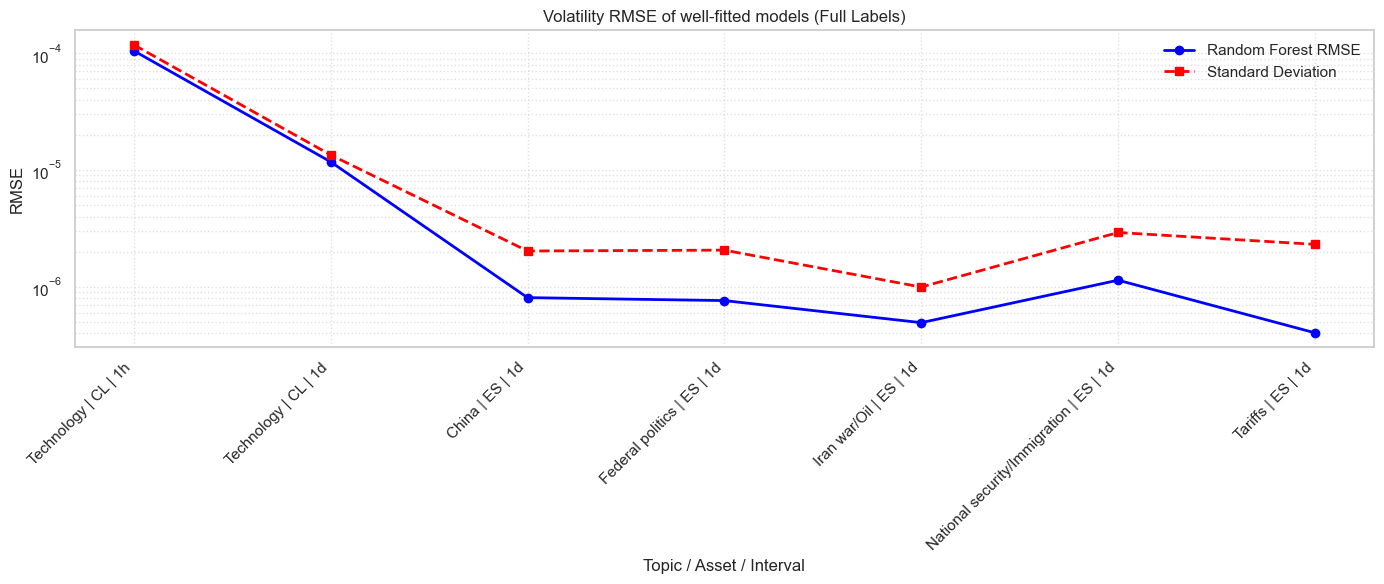

Saved figures with full labels to results/ folder!


In [160]:
# Select the well-fitted models
good_configs = [
    ('Technology', 'CL', '1h', 'Vol'),
    ('Technology', 'CL', '1d', 'Vol'),
    ('China', 'YM', '1h', 'Return'),
    ('China', 'YM', '1d', 'Return'),
    ('Federal politics', 'YM', '1d', 'Return'),
    ('Federal politics', 'I_NDX', '1d', 'Return')
]
for topic in ['China', 'Federal politics', 'Iran war/Oil', 'National security/Immigration', 'Tariffs']:
    good_configs.append((topic, 'ES', '1d', 'Return'))
    good_configs.append((topic, 'ES', '1d', 'Vol'))

# Separate good_configs into returns and volatilities
ret_configs = [c for c in good_configs if c[3] == 'Return']
vol_configs = [c for c in good_configs if c[3] == 'Vol']

df_reg_ret_list = []
for config in ret_configs:
    match = df_reg[(df_reg['Topic'] == config[0]) & 
                   (df_reg['Asset'] == config[1]) & 
                   (df_reg['Interval'] == config[2]) & 
                   (df_reg['Target param'] == config[3])]
    if not match.empty:
        df_reg_ret_list.append(match)
df_reg_ret = pd.concat(df_reg_ret_list, ignore_index=True) if df_reg_ret_list else pd.DataFrame()

df_reg_vol_list = []
for config in vol_configs:
    match = df_reg[(df_reg['Topic'] == config[0]) & 
                   (df_reg['Asset'] == config[1]) & 
                   (df_reg['Interval'] == config[2]) & 
                   (df_reg['Target param'] == config[3])]
    if not match.empty:
        df_reg_vol_list.append(match)
df_reg_vol = pd.concat(df_reg_vol_list, ignore_index=True) if df_reg_vol_list else pd.DataFrame()

# Construct full x-axis labels
if not df_reg_ret.empty:
    df_reg_ret['Full_Label'] = df_reg_ret.apply(lambda r: f"{r['Topic']} | {r['Asset']} | {r['Interval']}", axis=1)
if not df_reg_vol.empty:
    df_reg_vol['Full_Label'] = df_reg_vol.apply(lambda r: f"{r['Topic']} | {r['Asset']} | {r['Interval']}", axis=1)

# Plotting Returns RMSE and Standard Deviation
if not df_reg_ret.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(df_reg_ret['Full_Label'], df_reg_ret['RF_RMSE'], label='Random Forest RMSE', marker='o', color='blue', linewidth=2)
    plt.plot(df_reg_ret['Full_Label'], df_reg_ret['Target_Std'], label='Standard Deviation', marker='s', color='red', linestyle='--', linewidth=2)
    plt.legend()
    plt.xlabel('Topic | Asset | Interval')
    plt.ylabel('RMSE')
    plt.title('Returns RMSE of well-fitted models')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{results_dir}/returns_RMSE_good.png', dpi=300)
    plt.show()

# Plotting Volatility RMSE and Standard Deviation
if not df_reg_vol.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(df_reg_vol['Full_Label'], df_reg_vol['RF_RMSE'], label='Random Forest RMSE', marker='o', color='blue', linewidth=2)
    plt.plot(df_reg_vol['Full_Label'], df_reg_vol['Target_Std'], label='Standard Deviation', marker='s', color='red', linestyle='--', linewidth=2)
    plt.legend()
    plt.xlabel('Topic / Asset / Interval')
    plt.ylabel('RMSE')
    plt.yscale('log')
    plt.title('Volatility RMSE of well-fitted models (Full Labels)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{results_dir}/vol_RMSE.png', dpi=300)
    plt.show()

print("Saved figures with full labels to results/ folder!")


## Feature Importance Analysis
We calculate and analyze the Mean Decrease in Impurity (MDI) feature importances using the estimators from the `MultiOutputRegressor` model. Specifically, we analyze and plot the feature importances of the "good" models (with $R^2 > 0.5$) described in the RMSE subsection.

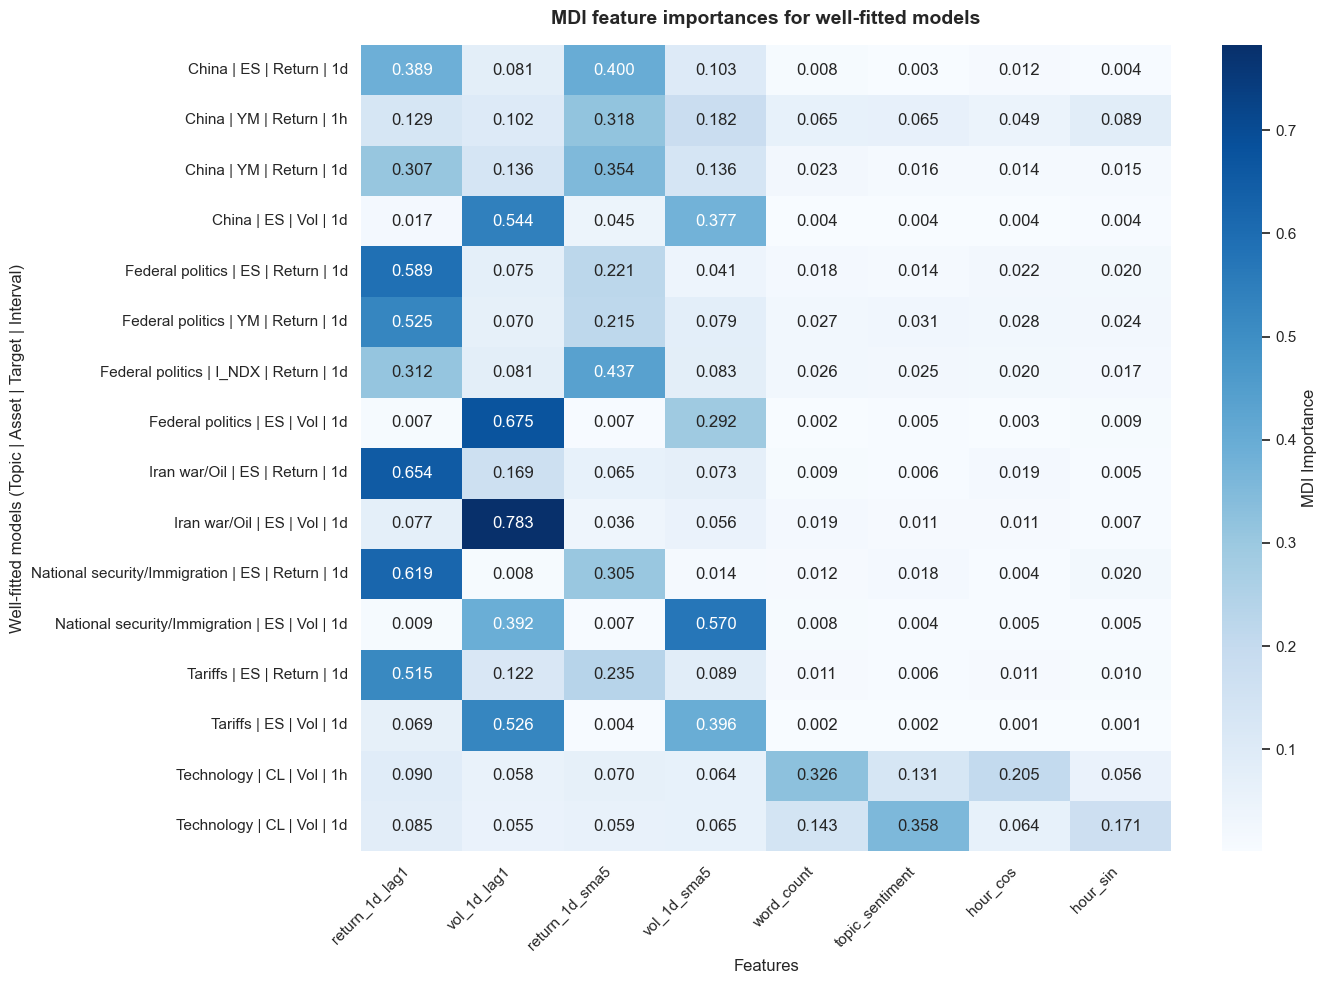

In [161]:
# Filter df_importances
mask = df_importances.apply(lambda r: (r['Topic'], r['Asset'], r['Interval'], r['Target param']) in good_configs, axis=1)
good_imp_df = df_importances[mask].copy()

# Add a label column for plotting
good_imp_df['Model_Label'] = good_imp_df.apply(
    lambda r: f"{r['Topic']} | {r['Asset']} | {r['Target param']} | {r['Interval']}", axis=1
)

importance_cols = [col for col in df_importances.columns if col not in ['Topic', 'Asset', 'Interval', 'Target param']]

# Calculate mean across good models
mean_importances = good_imp_df[importance_cols].mean().sort_values(ascending=False)

# Heatmap of Feature Importances
plt.figure(figsize=(14, 10))
sns.heatmap(
    good_imp_df.set_index('Model_Label')[mean_importances.index],
    annot=True,
    cmap='Blues',
    fmt='.3f',
    cbar_kws={'label': 'MDI Importance'}
)
plt.title('MDI feature importances for well-fitted models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Well-fitted models (Topic | Asset | Target | Interval)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{results_dir}/feature_importances_good_models.png', dpi=300)
plt.show()

## Binary Classification for Direction of Returns
We train 8 random forest classifier models on the 8 configurations that exhibited good regression fit ($R^2 > 0.5$) on Returns to predict the direction of returns (up or down). The chronological split (80% train, 20% test) is maintained to prevent look-ahead bias. The target variable is binarized such that $y_{\text{binary}} = 1$ if return $> 0$, else $0$. Performance is evaluated using Accuracy, Precision, Recall, and ROC AUC.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Select the 8 return models
classification_configs = [
    ('China', 'ES', '1d', 'Return', 'return_1d_ES'),
    ('Federal politics', 'ES', '1d', 'Return', 'return_1d_ES'),
    ('Iran war/Oil', 'ES', '1d', 'Return', 'return_1d_ES'),
    ('National security/Immigration', 'ES', '1d', 'Return', 'return_1d_ES'),
    ('Tariffs', 'ES', '1d', 'Return', 'return_1d_ES'),
    ('China', 'YM', '1d', 'Return', 'return_1d_YM'),
    ('Federal politics', 'YM', '1d', 'Return', 'return_1d_YM'),
    ('Federal politics', 'I_NDX', '1d', 'Return', 'return_1d_I_NDX')
]

results_classification = []
results_clf_importances = []

print('Starting binary classification training for predicting direction of returns...')
for topic, asset, interval, param, col_name in classification_configs:
    df_topic = df_final[df_final['topic'] == topic].copy()
    if len(df_topic) < 20:
        print(f'Skipping {topic} | {asset} | {interval} due to insufficient data.')
        continue
        
    # Sort chronologically to prevent look-ahead bias
    df_topic = df_topic.sort_values('timestamp_utc')
    
    # Input features, 8 dimensions.
    topic_sent_col = f'topic_{topic}_sentiment'
    input_cols = [ 
        'word_count', 'hour_sin', 'hour_cos',
        'return_1d_lag1', 'vol_1d_lag1',
        'return_1d_sma5', 'vol_1d_sma5',
        topic_sent_col
    ]
    
    X = df_topic[input_cols].values
    y_raw = df_topic[col_name].values
    y_binary = (y_raw > 0).astype(int)
    
    # Split into training and test sets
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y_binary[:split_idx], y_binary[split_idx:]
    
    # Skip if train or test has only one class
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f'Skipping {topic} | {asset} | {interval} due to single-class target in train or test.')
        continue
        
    # Train Random Forest classifier model
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    # Predictions
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    # Baseline accuracy is the proportion of the majority class in the test set, before model fitting.
    baseline_acc = max(np.mean(y_test), 1 - np.mean(y_test))
    
    results_classification.append({
        'Topic': topic,
        'Asset': asset,
        'Interval': interval,
        'Target param': param,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'ROC_AUC': auc,
        'Baseline_Accuracy': baseline_acc
    })
    
    # Store feature importances
    importances = clf.feature_importances_
    results_clf_importances.append({
        'Topic': topic,
        'Asset': asset,
        'Interval': interval,
        'Target param': param,
        'word_count': importances[0],
        'hour_sin': importances[1],
        'hour_cos': importances[2],
        'return_1d_lag1': importances[3],
        'vol_1d_lag1': importances[4],
        'return_1d_sma5': importances[5],
        'vol_1d_sma5': importances[6],
        'topic_sentiment': importances[7]
    })

df_clf_metrics = pd.DataFrame(results_classification)
df_clf_importances = pd.DataFrame(results_clf_importances)

print('\n=== Summary of Classification Metrics ===')
print(df_clf_metrics.to_string(index=False))

# Save to CSV files
results_dir = 'results' if os.path.exists('results') else '../../results'
os.makedirs(results_dir, exist_ok=True)
df_clf_metrics.to_csv(f'{results_dir}/model_classification_metrics.csv', index=False)
df_clf_importances.to_csv(f'{results_dir}/model_classification_feature_importances.csv', index=False)
print(f'\nClassification performance and feature importances written to results/ folder!')

Starting binary classification training across well-fitted return targets...

=== Summary of Classification Metrics ===
                        Topic Asset Interval Target param  Accuracy  Precision   Recall  ROC_AUC  Baseline_Accuracy
                        China    ES       1d       Return  0.857143   1.000000 0.600000 0.800000           0.642857
             Federal politics    ES       1d       Return  0.917676   0.882353 0.914634 0.949358           0.602906
                 Iran war/Oil    ES       1d       Return  0.540541   0.409091 0.692308 0.697115           0.648649
National security/Immigration    ES       1d       Return  0.882979   0.833333 0.740741 0.905473           0.712766
                      Tariffs    ES       1d       Return  0.851064   0.857143 0.818182 0.930000           0.531915
                        China    YM       1d       Return  0.714286   1.000000 0.500000 0.718750           0.571429
             Federal politics    YM       1d       Return  0.728814 

### Plot of Performance Metrics

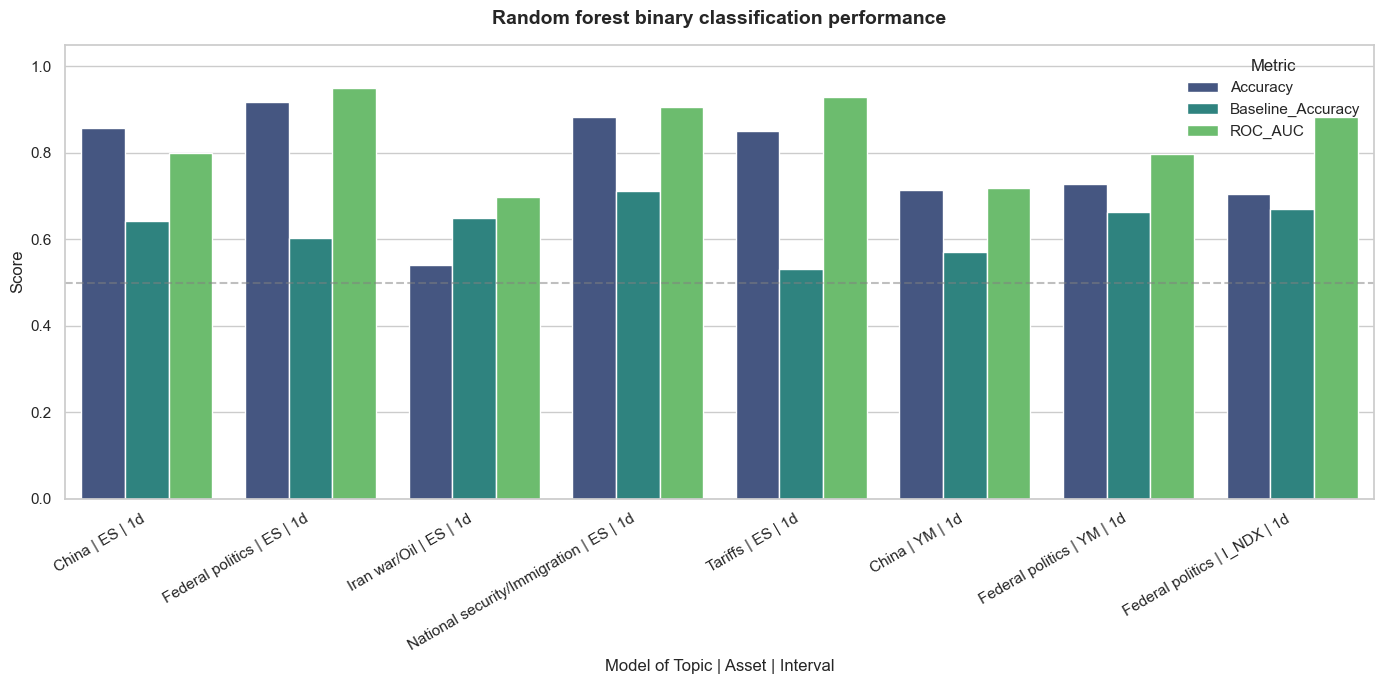

In [158]:
# Plotting Classification Performance
df_clf_melted = df_clf_metrics.melt(
    id_vars=['Topic', 'Asset', 'Interval'],
    value_vars=['Accuracy', 'Baseline_Accuracy', 'ROC_AUC'],
    var_name='Metric', 
    value_name='Score'
)

df_clf_melted['Model'] = df_clf_melted.apply(
    lambda r: f"{r['Topic']} | {r['Asset']} | {r['Interval']}", axis=1
)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_clf_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Random forest binary classification performance', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score')
plt.xlabel('Model of Topic | Asset | Interval')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{results_dir}/classification_performance.png', dpi=300)
plt.show()

### Feature Importance Analysis of Binary Classification

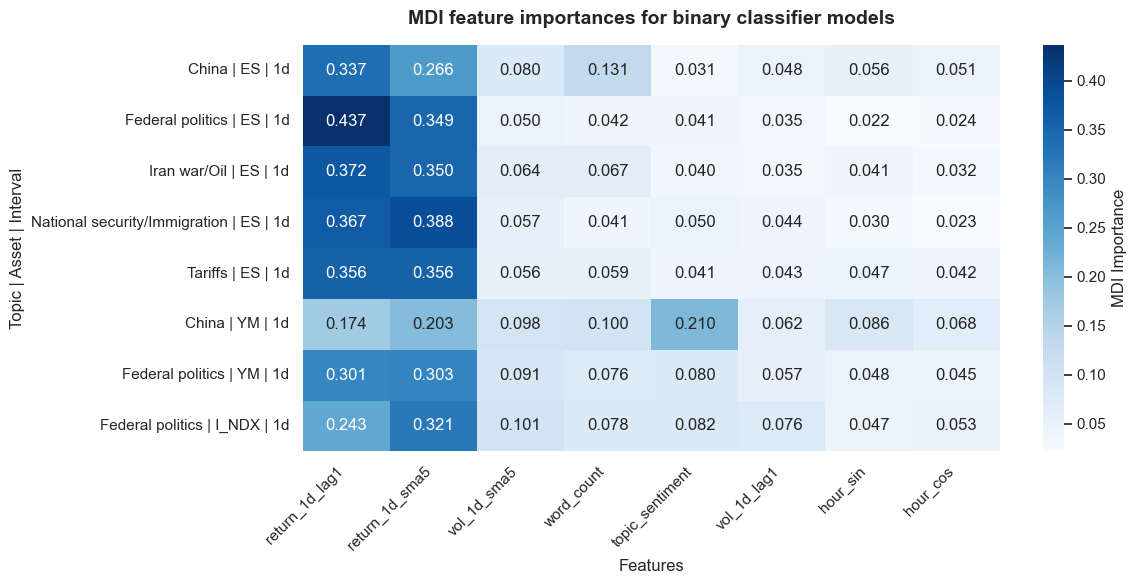

In [164]:
# Plotting Classification Feature Importances
df_clf_importances['Model_Label'] = df_clf_importances.apply(
    lambda r: f"{r['Topic']} | {r['Asset']} | {r['Interval']}", axis=1
)

# Feature columns
clf_feature_cols = [
    'word_count', 'hour_sin', 'hour_cos',
    'return_1d_lag1', 'vol_1d_lag1',
    'return_1d_sma5', 'vol_1d_sma5',
    'topic_sentiment'
]

# Calculate mean importance to sort features
mean_clf_importances = df_clf_importances[clf_feature_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.heatmap(
    df_clf_importances.set_index('Model_Label')[mean_clf_importances.index],
    annot=True,
    cmap='Blues',
    fmt='.3f',
    cbar_kws={'label': 'MDI Importance'}
)
plt.title('MDI feature importances for binary classifier models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Topic | Asset | Interval', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{results_dir}/classification_feature_importances.png', dpi=300)
plt.show()
